In [483]:
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mplsoccer import VerticalPitch


sys.path.append("../")
from xThreat import xThreat

In [484]:
n_x = 16
n_y = 12

In [485]:
xT_true_16x12 = xThreat.load_from_pickle(f'../0-model-storage/xt-full-data-n_x{16}-n_y{12}.pickle')
xT_true_32x24 = xThreat.load_from_pickle(f'../0-model-storage/xt-full-data-n_x{32}-n_y{24}.pickle')
xT_true_64x48 = xThreat.load_from_pickle(f'../0-model-storage/xt-full-data-n_x{64}-n_y{48}.pickle')


In [486]:
df_euros = pd.read_parquet('../1-data-preparation/data-storage/xThreat_datav3_euros2020.parquet')

In [487]:
df_euros.describe()

,x,y,possession,possession_length,chain_length,match_id,period,player_id,shot_statsbomb_xg,under_pressure,next_x,next_y,next_under_pressure,next_team_id,next_player_id
count,92654.000000,92654.000000,92654.000000,92654.000000,92654.000000,9.265400e+04,92654.000000,92654.000000,619.000000,20416.0,92654.000000,92654.000000,20407.0,92654.000000,92654.000000
mean,51.333875,33.650458,89.303743,12.809172,8.329559,3.790811e+06,1.574417,10128.393291,0.140505,1.0,51.345598,33.648096,1.0,886.433538,10129.786906
std,23.291350,19.858639,55.170866,13.628198,10.101545,2.917399e+03,0.660055,8483.507971,0.196433,0.0,23.296198,19.857529,0.0,273.628451,8485.351214
min,0.350000,0.085000,2.000000,0.000000,0.000000,3.788741e+06,1.000000,2954.000000,0.004871,1.0,0.350000,0.085000,1.0,768.000000,2954.000000
25%,35.087500,16.171250,43.000000,3.000000,1.000000,3.788754e+06,1.000000,4870.000000,0.035180,1.0,35.175000,16.235000,1.0,772.000000,4870.000000
50%,50.925000,33.405000,85.000000,8.000000,5.000000,3.788767e+06,2.000000,6954.000000,0.060380,1.0,50.925000,33.405000,1.0,785.000000,6954.000000
75%,68.250000,51.085000,131.000000,18.000000,12.000000,3.794688e+06,2.000000,11514.000000,0.139786,1.0,68.250000,51.085000,1.0,912.000000,11514.000000
max,104.650000,67.915000,275.000000,119.000000,103.000000,3.795506e+06,5.000000,73852.000000,0.963011,1.0,104.650000,67.915000,1.0,2358.000000,73852.000000


In [488]:
player_ids = df_euros['player_id'].unique().tolist()

In [489]:
df_euros

,x,y,possession_kept,possession,possession_length,chain_length,previous_deleted,match_id,id,period,...,shot_outcome,shot_statsbomb_xg,pass_height,under_pressure,next_type,next_x,next_y,next_under_pressure,next_team_id,next_player_id
index,,,,,,,,,,,,,,,,,,,,,
2088,13.8250,6.375,True,3,0,0,True,3788741,4cbd1088-1580-43f5-8b09-58efabb753ff,1,...,None,NaN,None,NaN,Pass,2.8875,10.795,NaN,914.0,6954.0
9,2.8875,10.795,True,3,2,1,False,3788741,bfcfd5ad-1dda-44c9-9f3d-9b33b59983a6,1,...,None,NaN,Ground Pass,NaN,Carry,6.9125,30.770,NaN,914.0,7036.0
2089,6.9125,30.770,True,3,3,2,False,3788741,58ef2997-552a-4d3e-854a-cf863f9f5b71,1,...,None,NaN,None,NaN,Pass,7.9625,33.065,NaN,914.0,7036.0
10,7.9625,33.065,True,3,4,3,False,3788741,14604dfa-65b1-40c0-a11e-7c6b037806c0,1,...,None,NaN,Ground Pass,NaN,Carry,17.2375,40.715,NaN,914.0,7173.0
2090,17.2375,40.715,True,3,5,4,False,3788741,5eae5d7a-59cb-42e0-bfc0-c5a2e80493ee,1,...,None,NaN,None,NaN,Pass,25.2000,42.415,NaN,914.0,7173.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4383,94.4125,34.000,False,215,0,0,False,3795506,4811f0d8-75a6-49c9-b8c1-31a74b3d065b,5,...,Saved,0.7835,None,NaN,Shot,94.5875,34.000,NaN,768.0,3336.0
4384,94.5875,34.000,False,216,0,0,False,3795506,7ca98b9e-d86b-4557-a73a-6b612d0f56ec,5,...,Goal,0.7835,None,NaN,Shot,94.3250,34.000,NaN,914.0,7173.0
4385,94.3250,34.000,False,217,0,0,False,3795506,f21ac35f-5ca3-4965-bf47-17786bef12ab,5,...,Goal,0.7835,None,NaN,Shot,94.5000,33.915,NaN,768.0,3318.0


In [490]:
from statsbombpy import sb
import pandas as pd

# Get all competitions and find UEFA Euro 2020
competitions = sb.competitions()
euro_2020 = competitions[
    (competitions['competition_name'] == 'UEFA Euro') & (competitions['season_name'] == '2020')
]
competition_id = euro_2020.iloc[0]['competition_id']
season_id = euro_2020.iloc[0]['season_id']

# Get all matches
matches = sb.matches(competition_id=competition_id, season_id=season_id)
match_ids = matches['match_id'].tolist()

# Dictionary to store player minutes
player_minutes = {}

# Loop through each match
for match_id in match_ids:
    events = sb.events(match_id)

    # Get match duration (accounting for extra time)
    max_minute = events['minute'].max()

    # Track player substitutions
    player_in_times = {}  # {player_id: entry_minute}
    player_out_times = {} # {player_id: exit_minute}

    for _, event in events.iterrows():
        if event['type'] == 'Substitution':
            player_off = event['player']
            player_on = event['substitution_replacement']
            minute = event['minute']

            if player_off:
                player_out_times[player_off] = minute
            if player_on:
                player_in_times[player_on] = minute

    # Calculate minutes for all players
    for player in events['player'].dropna().unique():
        start_minute = player_in_times.get(player, 0)  # Defaults to starting lineup (0 min)
        end_minute = player_out_times.get(player, max_minute)  # Defaults to full game

        minutes_played = end_minute - start_minute
        player_minutes[player] = player_minutes.get(player, 0) + minutes_played

# Convert to DataFrame
players_df = pd.DataFrame(player_minutes.items(), columns=['Player', 'Minutes'])

# Filter for players with at least 300 minutes
filtered_players = players_df[players_df['Minutes'] >= 300]

# Display result
print(filtered_players)


                         Player  Minutes
0    Álvaro Borja Morata Martín      455
1          Pau Francisco Torres      395
2               Aymeric Laporte      658
3              Jordi Alba Ramos      581
5    Jorge Resurrección Merodio      483
..                          ...      ...
358           Toby Alderweireld      378
359              Thorgan Hazard      375
362            Thibaut Courtois      471
363              Thomas Meunier      342
437             Benjamin Pavard      320

[146 rows x 2 columns]


In [491]:
position_mapping = {
    'Goalkeeper': 'Goalkeeper',
    'Right Back': 'Defender', 'Left Back': 'Defender', 'Center Back': 'Defender', 'Right Center Back': 'Defender', 'Left Center Back': 'Defender',
    'Right Wing Back': 'Defender', 'Left Wing Back': 'Defender', 
    'Center Defensive Midfield': 'Midfielder', 'Left Defensive Midfield': 'Midfielder', 'Right Defensive Midfield': 'Midfielder',
    'Central Midfield': 'Midfielder', 
    'Center Attacking Midfield': 'Midfielder', 'Right Attacking Midfield': 'Midfielder', 'Left Attacking Midfield': 'Midfielder',
    'Left Center Forward': 'Attacker', 'Right Center Forward': 'Attacker',
    'Right Midfield': 'Midfielder', 'Left Midfield': 'Midfielder', 'Right Center Midfield': 'Midfielder', 'Left Center Midfield': 'Midfielder',
    'Right Wing': 'Attacker', 'Left Wing': 'Attacker', 'Center Forward': 'Attacker', 'Second Striker': 'Attacker'
}

In [492]:
from statsbombpy import sb
import pandas as pd

# Get all competitions and find UEFA Euro 2020
competitions = sb.competitions()
euro_2020 = competitions[
    (competitions['competition_name'] == 'UEFA Euro') & (competitions['season_name'] == '2020')
]
competition_id = euro_2020.iloc[0]['competition_id']
season_id = euro_2020.iloc[0]['season_id']

# Get all matches
matches = sb.matches(competition_id=competition_id, season_id=season_id)
match_ids = matches['match_id'].tolist()

# Dictionary to store player minutes
player_minutes = {}

# Dictionary to store player positions
player_positions = {}

# Dictionary to store player names for each id
player_ids = {}

# Loop through each match
for match_id in match_ids:
    events = sb.events(match_id)
    
    # Get match duration (accounting for extra time)
    max_minute = events['minute'].max()

    # Track player substitutions
    player_in_times = {}  # {player_name: entry_minute}
    player_out_times = {} # {player_name: exit_minute}

    for _, event in events.iterrows():
        if event['type'] == 'Substitution':
            player_off = event['player']
            player_on = event['substitution_replacement']
            minute = event['minute']

            if player_off:
                player_out_times[player_off] = minute
            if player_on:
                player_in_times[player_on] = minute

    # Calculate minutes for all players
    for player in events['player'].dropna().unique():
        start_minute = player_in_times.get(player, 0)  # Defaults to starting lineup (0 min)
        end_minute = player_out_times.get(player, max_minute)  # Defaults to full game

        minutes_played = end_minute - start_minute
        player_minutes[player] = player_minutes.get(player, 0) + minutes_played

    # Get lineup data for this match
    lineup_data = sb.lineups(match_id)

    # Extract player positions (lineup_data is a dictionary of DataFrames)
    for team_name, lineup_df in lineup_data.items():
        for _, player in lineup_df.iterrows():
            player_name = player['player_name']
            player_id = player['player_id']
            player_ids[player_name] = player_id

            game_player_positions = player_positions.get(player_name, {'Goalkeeper': 0, 'Defender': 0, 'Midfielder': 0, 'Attacker': 0})
            for position in player['positions']:
                game_player_positions[position_mapping[position['position']]] += 1
                
            player_positions[player_name] = game_player_positions

# Convert minutes to DataFrame
players_df = pd.DataFrame(player_minutes.items(), columns=['Player', 'Minutes'])

player_ids = pd.DataFrame(player_ids.items(), columns = ['Player', 'player_id'])

# Convert positions to DataFrame
player_names = player_positions.keys()
goalkeeper, defender, midfielder, attacker = [], [], [], []
for player_name in player_names:
    goalkeeper.append(player_positions[player_name]['Goalkeeper'])
    defender.append(player_positions[player_name]['Defender'])
    midfielder.append(player_positions[player_name]['Midfielder'])
    attacker.append(player_positions[player_name]['Attacker'])

positions_df = pd.DataFrame({
    'Player': player_names,
    'goalkeeper': goalkeeper,
    'defender': defender,
    'midfielder': midfielder,
    'attacker': attacker,
})
positions_df["main_position"] = positions_df[["goalkeeper", "defender", "midfielder", "attacker"]].idxmax(axis=1)


# Merge DataFrames
players_df = players_df.merge(positions_df, on='Player', how='left')
players_df = players_df.merge(player_ids, on='Player', how='left')

# Filter for players with at least 300 minutes
filtered_players = players_df[players_df['Minutes'] >= 300]

# Define broader position categories


# Display result
print(filtered_players)


                         Player  Minutes  goalkeeper  defender  midfielder  \
0    Álvaro Borja Morata Martín      455           0         0           0   
1          Pau Francisco Torres      395           0        10           0   
2               Aymeric Laporte      658           0        12           0   
3              Jordi Alba Ramos      581           0         6           0   
5    Jorge Resurrección Merodio      483           0         0           6   
..                          ...      ...         ...       ...         ...   
358           Toby Alderweireld      378           0         4           0   
359              Thorgan Hazard      375           0         5           0   
362            Thibaut Courtois      471           5         0           0   
363              Thomas Meunier      342           0         5           0   
437             Benjamin Pavard      320           0         4           0   

     attacker main_position  player_id  
0           8      att

In [493]:
players_df

,Player,Minutes,goalkeeper,defender,midfielder,attacker,main_position,player_id
0,Álvaro Borja Morata Martín,455,0,0,0,8,attacker,3477
1,Pau Francisco Torres,395,0,10,0,0,defender,6892
2,Aymeric Laporte,658,0,12,0,0,defender,4353
3,Jordi Alba Ramos,581,0,6,0,0,defender,5211
4,Pablo Sarabia García,267,0,0,1,10,attacker,6720
...,...,...,...,...,...,...,...,...
485,Andrey Semenov,91,0,2,0,0,defender,34588
486,Anton Shunin,91,1,0,0,0,goalkeeper,38119
487,Timothy Castagne,26,0,1,0,0,defender,6989
488,Yuri Zhirkov,42,0,1,0,0,defender,5193


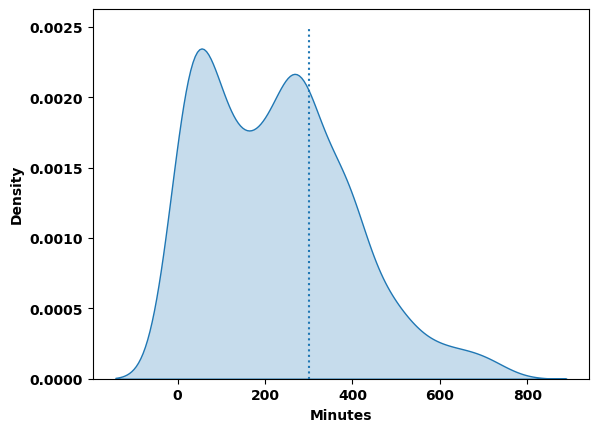

In [494]:
import seaborn as sns

ax = sns.kdeplot(data=players_df, x='Minutes', fill=True)
ax.plot([300, 300], [0,0.0025], ":")

In [495]:
filtered_players.head()

,Player,Minutes,goalkeeper,defender,midfielder,attacker,main_position,player_id
0,Álvaro Borja Morata Martín,455,0,0,0,8,attacker,3477
1,Pau Francisco Torres,395,0,10,0,0,defender,6892
2,Aymeric Laporte,658,0,12,0,0,defender,4353
3,Jordi Alba Ramos,581,0,6,0,0,defender,5211
5,Jorge Resurrección Merodio,483,0,0,6,0,midfielder,5199


# Filter on players with at least 300 minutes

In [496]:
filtered_player_ids = filtered_players['player_id']
filtered_player_ids

0       3477
1       6892
2       4353
3       5211
5       5199
       ...  
358    20005
359     5632
362     3509
363     3176
437     5476
Name: player_id, Length: 146, dtype: int64

In [497]:
df_euros

,x,y,possession_kept,possession,possession_length,chain_length,previous_deleted,match_id,id,period,...,shot_outcome,shot_statsbomb_xg,pass_height,under_pressure,next_type,next_x,next_y,next_under_pressure,next_team_id,next_player_id
index,,,,,,,,,,,,,,,,,,,,,
2088,13.8250,6.375,True,3,0,0,True,3788741,4cbd1088-1580-43f5-8b09-58efabb753ff,1,...,None,NaN,None,NaN,Pass,2.8875,10.795,NaN,914.0,6954.0
9,2.8875,10.795,True,3,2,1,False,3788741,bfcfd5ad-1dda-44c9-9f3d-9b33b59983a6,1,...,None,NaN,Ground Pass,NaN,Carry,6.9125,30.770,NaN,914.0,7036.0
2089,6.9125,30.770,True,3,3,2,False,3788741,58ef2997-552a-4d3e-854a-cf863f9f5b71,1,...,None,NaN,None,NaN,Pass,7.9625,33.065,NaN,914.0,7036.0
10,7.9625,33.065,True,3,4,3,False,3788741,14604dfa-65b1-40c0-a11e-7c6b037806c0,1,...,None,NaN,Ground Pass,NaN,Carry,17.2375,40.715,NaN,914.0,7173.0
2090,17.2375,40.715,True,3,5,4,False,3788741,5eae5d7a-59cb-42e0-bfc0-c5a2e80493ee,1,...,None,NaN,None,NaN,Pass,25.2000,42.415,NaN,914.0,7173.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4383,94.4125,34.000,False,215,0,0,False,3795506,4811f0d8-75a6-49c9-b8c1-31a74b3d065b,5,...,Saved,0.7835,None,NaN,Shot,94.5875,34.000,NaN,768.0,3336.0
4384,94.5875,34.000,False,216,0,0,False,3795506,7ca98b9e-d86b-4557-a73a-6b612d0f56ec,5,...,Goal,0.7835,None,NaN,Shot,94.3250,34.000,NaN,914.0,7173.0
4385,94.3250,34.000,False,217,0,0,False,3795506,f21ac35f-5ca3-4965-bf47-17786bef12ab,5,...,Goal,0.7835,None,NaN,Shot,94.5000,33.915,NaN,768.0,3318.0


In [498]:
mask = df_euros['player_id'].isin(filtered_player_ids)
df_euros_filtered = df_euros[mask].copy()
df_euros_filtered

,x,y,possession_kept,possession,possession_length,chain_length,previous_deleted,match_id,id,period,...,shot_outcome,shot_statsbomb_xg,pass_height,under_pressure,next_type,next_x,next_y,next_under_pressure,next_team_id,next_player_id
index,,,,,,,,,,,,,,,,,,,,,
2088,13.8250,6.375,True,3,0,0,True,3788741,4cbd1088-1580-43f5-8b09-58efabb753ff,1,...,None,NaN,None,NaN,Pass,2.8875,10.795,NaN,914.0,6954.0
9,2.8875,10.795,True,3,2,1,False,3788741,bfcfd5ad-1dda-44c9-9f3d-9b33b59983a6,1,...,None,NaN,Ground Pass,NaN,Carry,6.9125,30.770,NaN,914.0,7036.0
2089,6.9125,30.770,True,3,3,2,False,3788741,58ef2997-552a-4d3e-854a-cf863f9f5b71,1,...,None,NaN,None,NaN,Pass,7.9625,33.065,NaN,914.0,7036.0
10,7.9625,33.065,True,3,4,3,False,3788741,14604dfa-65b1-40c0-a11e-7c6b037806c0,1,...,None,NaN,Ground Pass,NaN,Carry,17.2375,40.715,NaN,914.0,7173.0
2090,17.2375,40.715,True,3,5,4,False,3788741,5eae5d7a-59cb-42e0-bfc0-c5a2e80493ee,1,...,None,NaN,None,NaN,Pass,25.2000,42.415,NaN,914.0,7173.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3783,88.3750,66.045,True,210,20,20,False,3795506,d554972c-7ce9-4698-84e9-fb2b01fbfd97,4,...,None,NaN,None,NaN,Pass,71.0500,44.710,1.0,768.0,10955.0
1358,71.0500,44.710,False,211,0,0,True,3795506,22f76976-9167-4bc4-9ccb-66560d849b4a,4,...,None,NaN,High Pass,1.0,Shot,94.5000,34.000,NaN,768.0,10955.0
4382,94.5000,34.000,False,214,0,0,True,3795506,526593d2-c545-4433-aa71-f923a7dd7811,5,...,Goal,0.7835,None,NaN,Shot,94.4125,34.000,NaN,914.0,7471.0


# Visualisation of the distribution

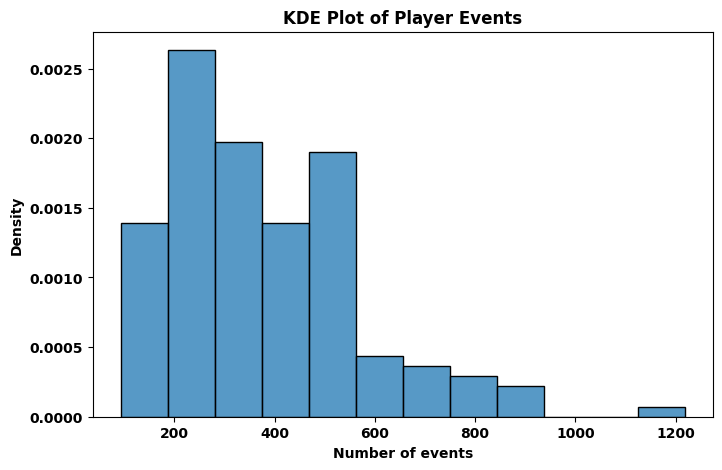

In [499]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Count occurrences of each player_id
player_counts = df_euros_filtered['player_id'].value_counts()

# Plot KDE
plt.figure(figsize=(8, 5))
sns.histplot(player_counts, fill=True, stat='density')
plt.xlabel('Number of events')
plt.ylabel('Density')
plt.title('KDE Plot of Player Events')
plt.show()


In [500]:
df_euros_filtered['shot'] = ~df_euros_filtered['shot_outcome'].isna()
df_euros_filtered['goal'] = df_euros_filtered['shot_outcome'] == 'Goal'

## True model 16x12

In [503]:
df_euros_filtered = xT_true_16x12.quantify_action_quality(df_euros_filtered)
df_positive = df_euros_filtered[df_euros_filtered['action_xT'] > 0]
df_positive = df_positive.merge(filtered_players[['player_id', 'Minutes', 'main_position']], on='player_id', how='left')
df_positive['action_xT_sum'] = df_positive['action_xT']
df_positive['action_xT'] = df_positive['action_xT'] / df_positive['Minutes'] * 90

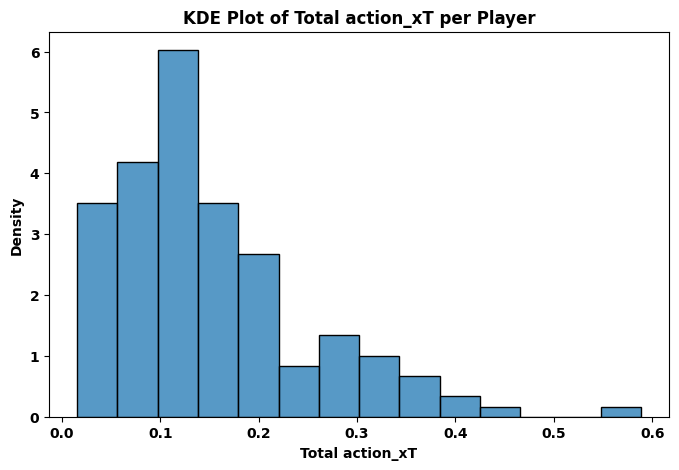

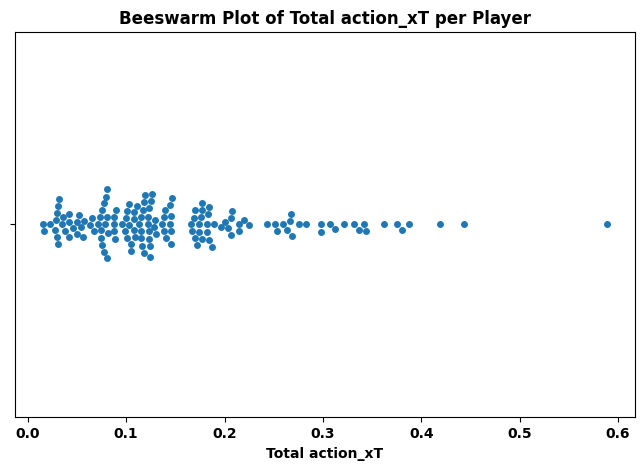

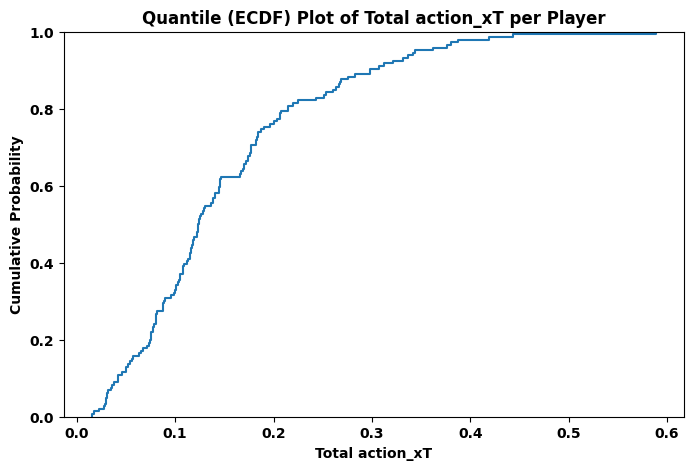

In [504]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Group by player_id and sum action_xT
player_xT_sum = df_positive.groupby('player_id')['action_xT'].sum()

# Create KDE plot
plt.figure(figsize=(8, 5))
sns.histplot(player_xT_sum, fill=True, stat='density')
plt.xlabel('Total action_xT')
plt.ylabel('Density')
plt.title('KDE Plot of Total action_xT per Player')
plt.show()

# Create a beeswarm plot
plt.figure(figsize=(8, 5))
sns.swarmplot(x=player_xT_sum, orient='h', size=5)
plt.xlabel('Total action_xT')
plt.title('Beeswarm Plot of Total action_xT per Player')
plt.show()

# Alternative: Create a quantile plot (ECDF)
plt.figure(figsize=(8, 5))
sns.ecdfplot(player_xT_sum)
plt.xlabel('Total action_xT')
plt.ylabel('Cumulative Probability')
plt.title('Quantile (ECDF) Plot of Total action_xT per Player')
plt.show()


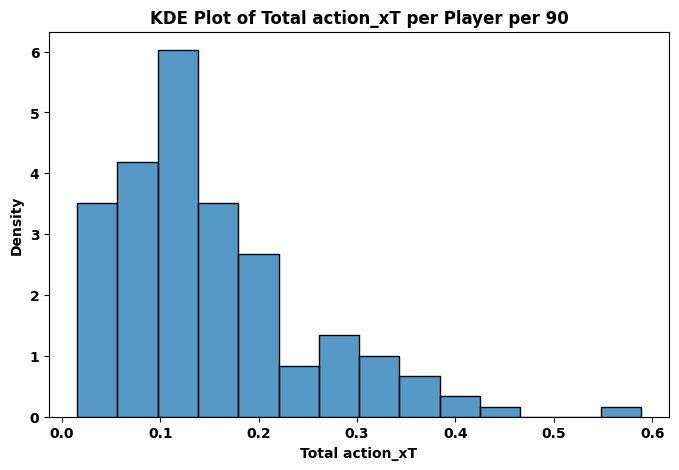

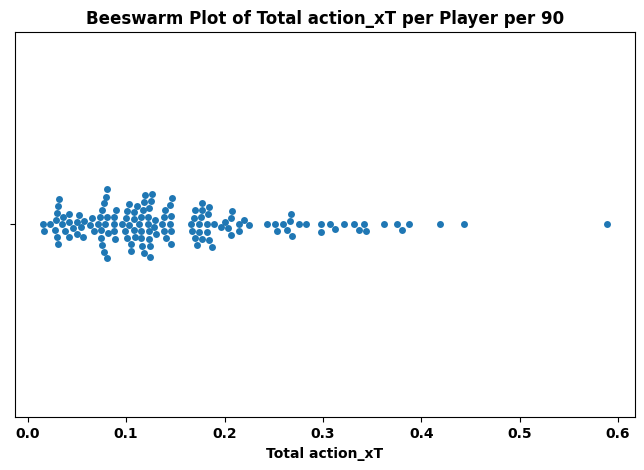

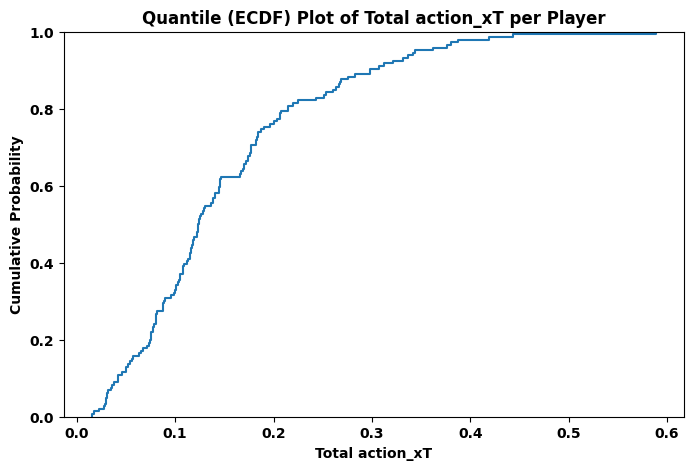

In [505]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Group by player_id and sum action_xT
player_xT_sum = df_positive.groupby('player_id')['action_xT'].sum()

# Create KDE plot
plt.figure(figsize=(8, 5))
sns.histplot(player_xT_sum, fill=True, stat='density')
plt.xlabel('Total action_xT')
plt.ylabel('Density')
plt.title('KDE Plot of Total action_xT per Player per 90')
plt.show()

# Create a beeswarm plot
plt.figure(figsize=(8, 5))
sns.swarmplot(x=player_xT_sum, orient='h', size=5)
plt.xlabel('Total action_xT')
plt.title('Beeswarm Plot of Total action_xT per Player per 90')
plt.show()

# Alternative: Create a quantile plot (ECDF)
plt.figure(figsize=(8, 5))
sns.ecdfplot(player_xT_sum)
plt.xlabel('Total action_xT')
plt.ylabel('Cumulative Probability')
plt.title('Quantile (ECDF) Plot of Total action_xT per Player')
plt.show()


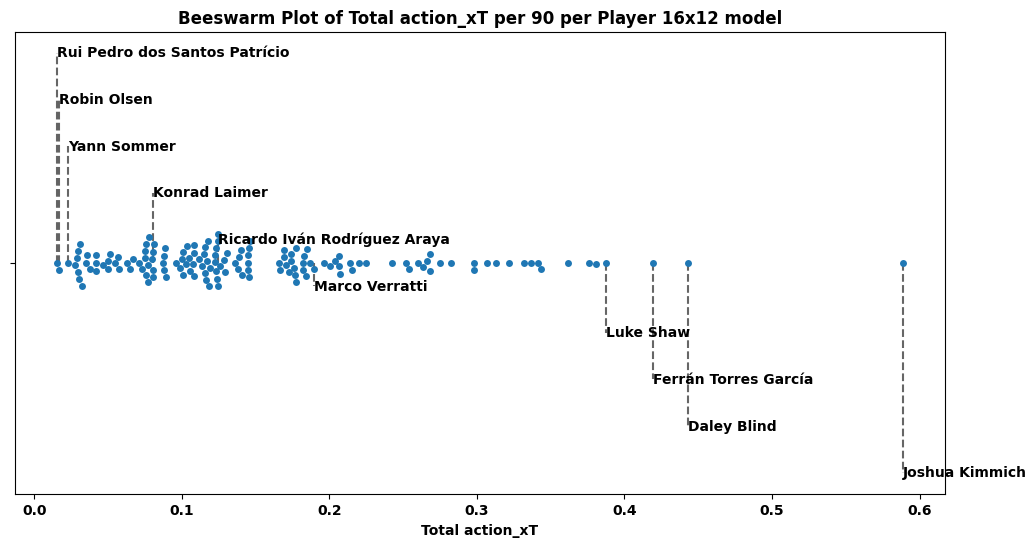

In [540]:
import numpy as np

# Merge player names into the player_xT_sum DataFrame
player_xT_df = player_xT_sum.reset_index().merge(filtered_players[['player_id', 'Player']], on='player_id')

# Sort values for annotation
player_xT_df = player_xT_df.sort_values('action_xT')

# Select some key points for annotation: min, max, and quartiles
key_indices = [0, 1, 2, len(player_xT_df) // 4, len(player_xT_df) // 2, 3 * len(player_xT_df) // 4, len(player_xT_df) - 4, len(player_xT_df) - 3, len(player_xT_df) - 2, len(player_xT_df) - 1]
key_players = player_xT_df.iloc[key_indices]

# Create beeswarm plot
plt.figure(figsize=(12, 6))
ax = sns.swarmplot(x=player_xT_df['action_xT'], orient='h', size=5)

# Annotate selected points with lines and staggered text positions
y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
for i, (_, row) in enumerate(key_players.iterrows()):
    plt.plot([row['action_xT'], row['action_xT']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
    plt.text(row['action_xT'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

plt.xlabel('Total action_xT')
plt.title('Beeswarm Plot of Total action_xT per 90 per Player 16x12 model')
plt.show()


## True model 64x48

In [507]:
df_euros_filtered_64x48 = xT_true_64x48.quantify_action_quality(df_euros_filtered)
df_positive_64x48 = df_euros_filtered_64x48[df_euros_filtered_64x48['action_xT'] > 0]
df_positive_64x48 = df_positive_64x48.merge(filtered_players[['player_id', 'Minutes', 'main_position']], on='player_id', how='left')
df_positive_64x48['action_xT_sum'] = df_positive_64x48['action_xT']
df_positive_64x48['action_xT'] = df_positive_64x48['action_xT'] / df_positive_64x48['Minutes'] * 90

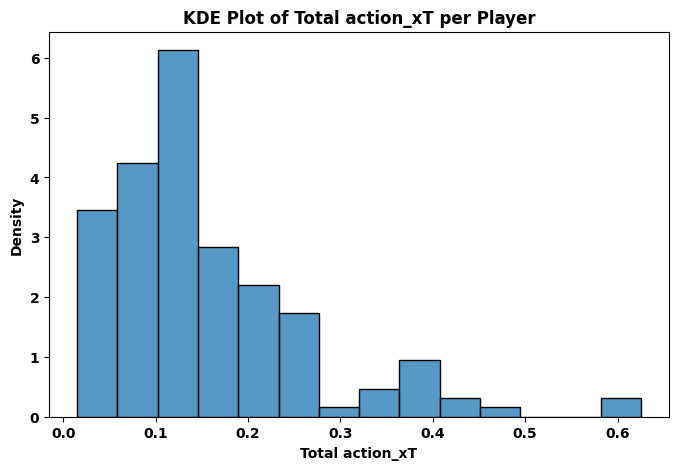

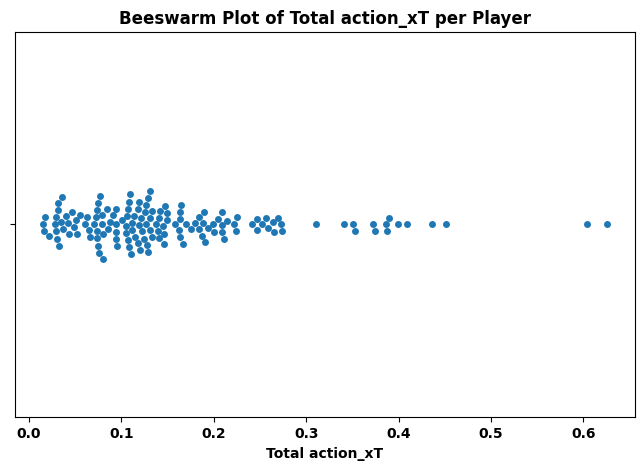

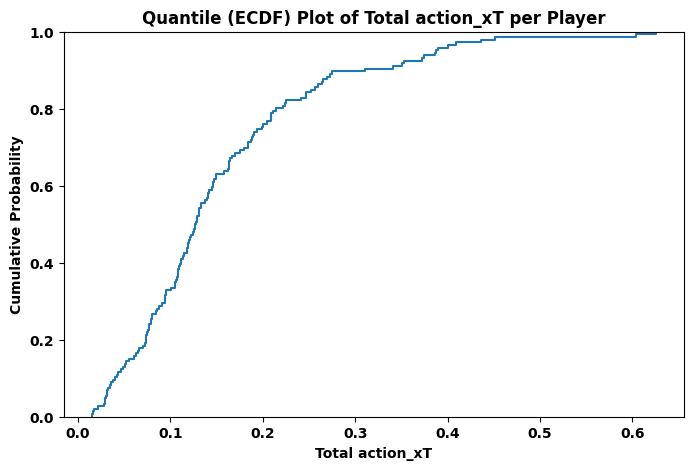

In [508]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Group by player_id and sum action_xT
player_xT_sum_64x48 = df_positive_64x48.groupby('player_id')['action_xT'].sum()

# Create KDE plot
plt.figure(figsize=(8, 5))
sns.histplot(player_xT_sum_64x48, fill=True, stat='density')
plt.xlabel('Total action_xT')
plt.ylabel('Density')
plt.title('KDE Plot of Total action_xT per Player')
plt.show()

# Create a beeswarm plot
plt.figure(figsize=(8, 5))
sns.swarmplot(x=player_xT_sum_64x48, orient='h', size=5)
plt.xlabel('Total action_xT')
plt.title('Beeswarm Plot of Total action_xT per Player')
plt.show()

# Alternative: Create a quantile plot (ECDF)
plt.figure(figsize=(8, 5))
sns.ecdfplot(player_xT_sum_64x48)
plt.xlabel('Total action_xT')
plt.ylabel('Cumulative Probability')
plt.title('Quantile (ECDF) Plot of Total action_xT per Player')
plt.show()


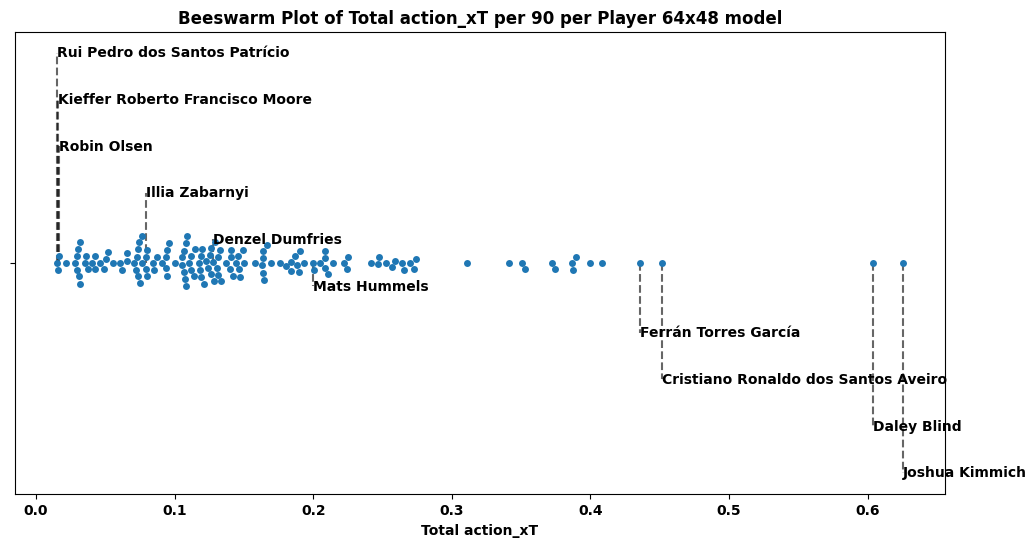

In [541]:
import numpy as np

# Merge player names into the player_xT_sum DataFrame
player_xT_df_64x48 = player_xT_sum_64x48.reset_index().merge(filtered_players[['player_id', 'Player']], on='player_id')

# Sort values for annotation
player_xT_df_64x48 = player_xT_df_64x48.sort_values('action_xT')

# Select some key points for annotation: min, max, and quartiles
key_indices = [0, 1, 2, len(player_xT_df_64x48) // 4, len(player_xT_df_64x48) // 2, 3 * len(player_xT_df_64x48) // 4, len(player_xT_df_64x48) - 4, len(player_xT_df_64x48) - 3, len(player_xT_df_64x48) - 2, len(player_xT_df_64x48) - 1]
key_players = player_xT_df_64x48.iloc[key_indices]

# Create beeswarm plot
plt.figure(figsize=(12, 6))
ax = sns.swarmplot(x=player_xT_df_64x48['action_xT'], orient='h', size=5)

# Annotate selected points with lines and staggered text positions
y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
for i, (_, row) in enumerate(key_players.iterrows()):
    plt.plot([row['action_xT'], row['action_xT']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
    plt.text(row['action_xT'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

plt.xlabel('Total action_xT')
plt.title('Beeswarm Plot of Total action_xT per 90 per Player 64x48 model')
plt.show()


## True model 32x24

In [510]:
df_euros_filtered_32x24 = xT_true_32x24.quantify_action_quality(df_euros_filtered)
df_positive_32x24 = df_euros_filtered_32x24[df_euros_filtered_32x24['action_xT'] > 0]
df_positive_32x24 = df_positive_32x24.merge(filtered_players[['player_id', 'Minutes', 'main_position']], on='player_id', how='left')
df_positive_32x24['action_xT_sum'] = df_positive_32x24['action_xT']
df_positive_32x24['action_xT'] = df_positive_32x24['action_xT'] / df_positive_32x24['Minutes'] * 90

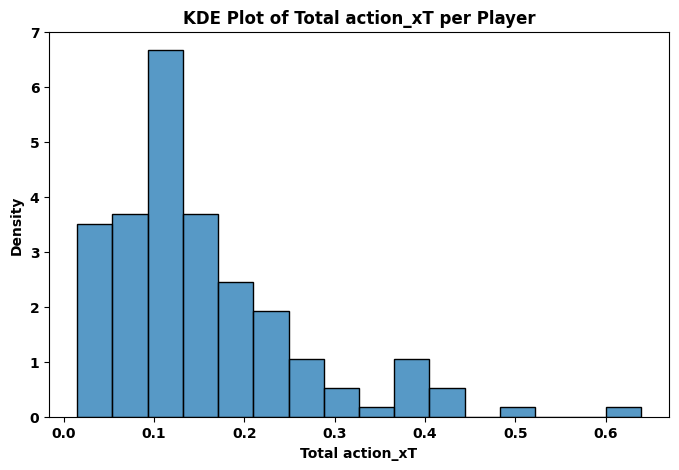

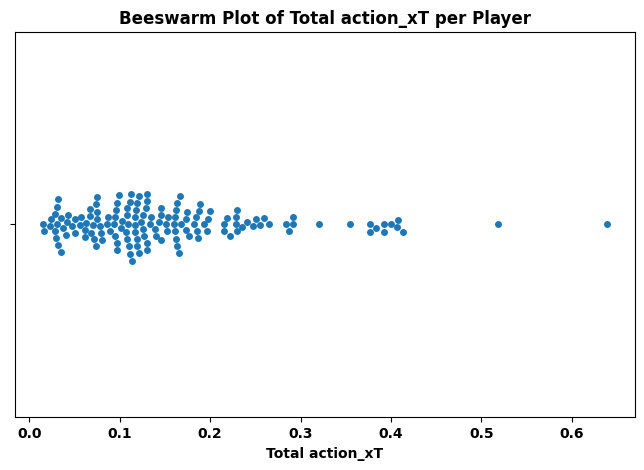

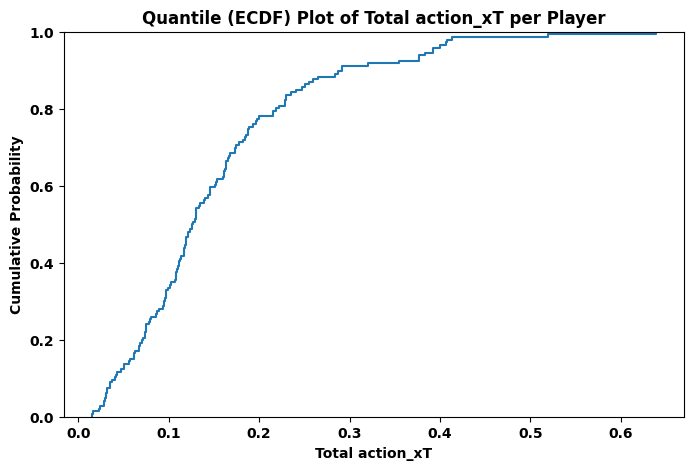

In [511]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Group by player_id and sum action_xT
player_xT_sum_32x24 = df_positive_32x24.groupby('player_id')['action_xT'].sum()

# Create KDE plot
plt.figure(figsize=(8, 5))
sns.histplot(player_xT_sum_32x24, fill=True, stat='density')
plt.xlabel('Total action_xT')
plt.ylabel('Density')
plt.title('KDE Plot of Total action_xT per Player')
plt.show()

# Create a beeswarm plot
plt.figure(figsize=(8, 5))
sns.swarmplot(x=player_xT_sum_32x24, orient='h', size=5)
plt.xlabel('Total action_xT')
plt.title('Beeswarm Plot of Total action_xT per Player')
plt.show()

# Alternative: Create a quantile plot (ECDF)
plt.figure(figsize=(8, 5))
sns.ecdfplot(player_xT_sum_32x24)
plt.xlabel('Total action_xT')
plt.ylabel('Cumulative Probability')
plt.title('Quantile (ECDF) Plot of Total action_xT per Player')
plt.show()

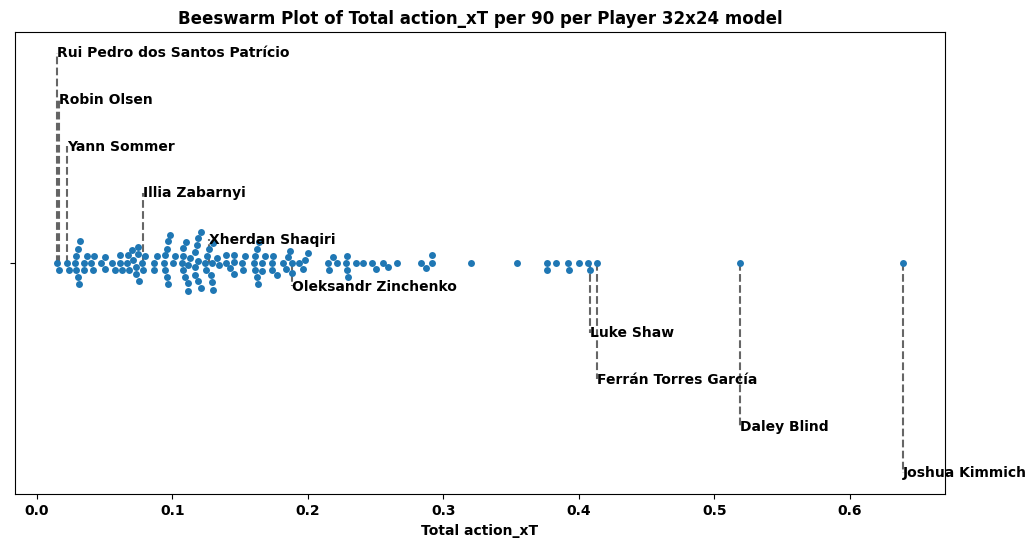

In [542]:

import numpy as np

# Merge player names into the player_xT_sum DataFrame
player_xT_df_32x24 = player_xT_sum_32x24.reset_index().merge(filtered_players[['player_id', 'Player']], on='player_id')

# Sort values for annotation
player_xT_df_32x24 = player_xT_df_32x24.sort_values('action_xT')

# Select some key points for annotation: min, max, and quartiles
key_indices = [0, 1, 2, len(player_xT_df_32x24) // 4, len(player_xT_df_32x24) // 2, 3 * len(player_xT_df_32x24) // 4, len(player_xT_df_32x24) - 4, len(player_xT_df_32x24) - 3, len(player_xT_df_32x24) - 2, len(player_xT_df_32x24) - 1]
key_players = player_xT_df_32x24.iloc[key_indices]

# Create beeswarm plot
plt.figure(figsize=(12, 6))
ax = sns.swarmplot(x=player_xT_df_32x24['action_xT'], orient='h', size=5)

# Annotate selected points with lines and staggered text positions
y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
for i, (_, row) in enumerate(key_players.iterrows()):
    plt.plot([row['action_xT'], row['action_xT']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
    plt.text(row['action_xT'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

plt.xlabel('Total action_xT')
plt.title('Beeswarm Plot of Total action_xT per 90 per Player 32x24 model')
plt.show()


## Look at difference between 16x12 and 64x48

In [515]:
combined_player_xT_df = player_xT_df.rename(columns={'action_xT': 'action_xT_16x12'}).merge(player_xT_df_64x48.drop(columns=['Player']).rename(columns={'action_xT': 'action_xT_64x48'}), on='player_id')
combined_player_xT_df = combined_player_xT_df.merge(player_xT_df_32x24.drop(columns=['Player']).rename(columns={'action_xT': 'action_xT_32x24'}), on='player_id')
combined_player_xT_df['diff_xT'] = combined_player_xT_df['action_xT_64x48'] - combined_player_xT_df['action_xT_16x12']
combined_player_xT_df

,player_id,action_xT_16x12,Player,action_xT_64x48,action_xT_32x24,diff_xT
0,5205.0,0.015535,Rui Pedro dos Santos Patrício,0.015173,0.015110,-0.000362
1,5622.0,0.017004,Robin Olsen,0.016872,0.016673,-0.000132
2,5550.0,0.023071,Yann Sommer,0.021728,0.022459,-0.001343
3,22243.0,0.027515,Heorhii Bushchan,0.027979,0.028256,0.000465
4,11748.0,0.029008,Unai Simón Mendibil,0.029190,0.028792,0.000182
...,...,...,...,...,...,...
141,2988.0,0.380419,Memphis Depay,0.389606,0.392511,0.009187
142,3382.0,0.387631,Luke Shaw,0.408600,0.407906,0.020969
143,6748.0,0.419439,Ferrán Torres García,0.435707,0.413007,0.016268
144,3311.0,0.442936,Daley Blind,0.604135,0.519068,0.161199


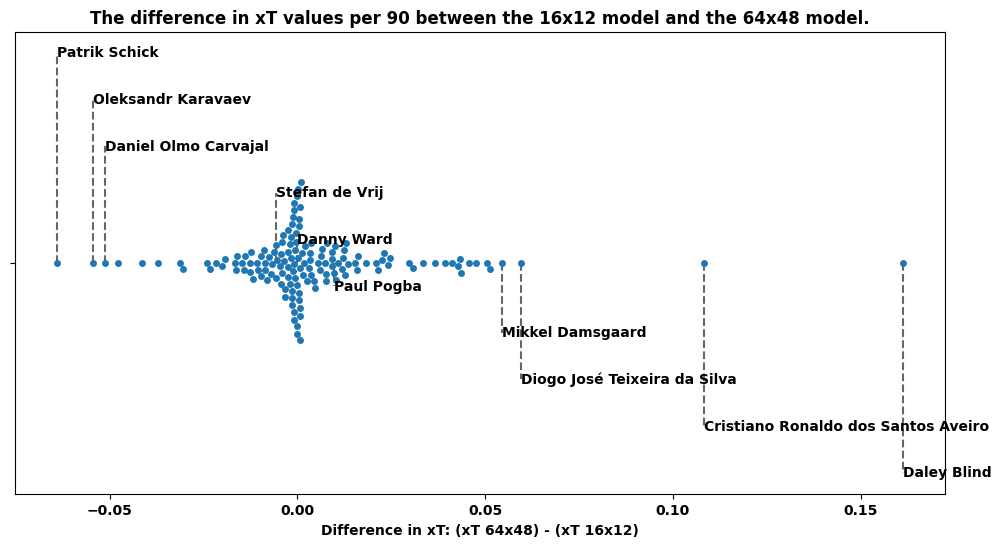

In [516]:
import numpy as np

# Sort values for annotation
combined_player_xT_df = combined_player_xT_df.sort_values('diff_xT')

# Select some key points for annotation: min, max, and quartiles
key_indices = [0, 1, 2, len(player_xT_df) // 4, len(combined_player_xT_df) // 2, 3 * len(combined_player_xT_df) // 4, len(combined_player_xT_df) - 4, len(combined_player_xT_df) - 3, len(combined_player_xT_df) - 2, len(combined_player_xT_df) - 1]
key_players = combined_player_xT_df.iloc[key_indices]

# Create beeswarm plot
plt.figure(figsize=(12, 6))
ax = sns.swarmplot(x=combined_player_xT_df['diff_xT'], orient='h', size=5)

# Annotate selected points with lines and staggered text positions
y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
for i, (_, row) in enumerate(key_players.iterrows()):
    plt.plot([row['diff_xT'], row['diff_xT']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
    plt.text(row['diff_xT'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

plt.xlabel('Difference in xT: (xT 64x48) - (xT 16x12)')
plt.title('The difference in xT values per 90 between the 16x12 model and the 64x48 model.')
plt.show()


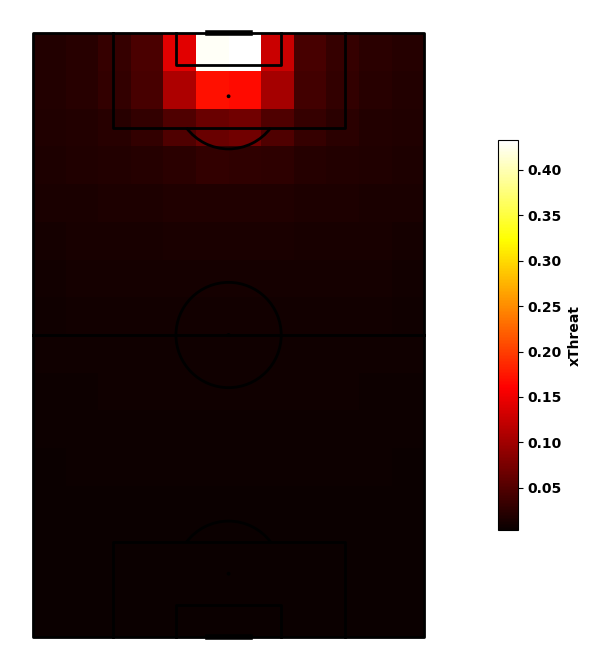

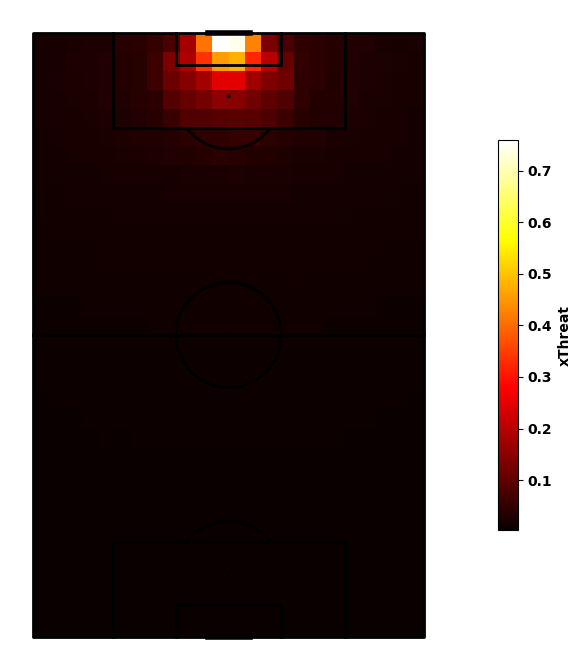

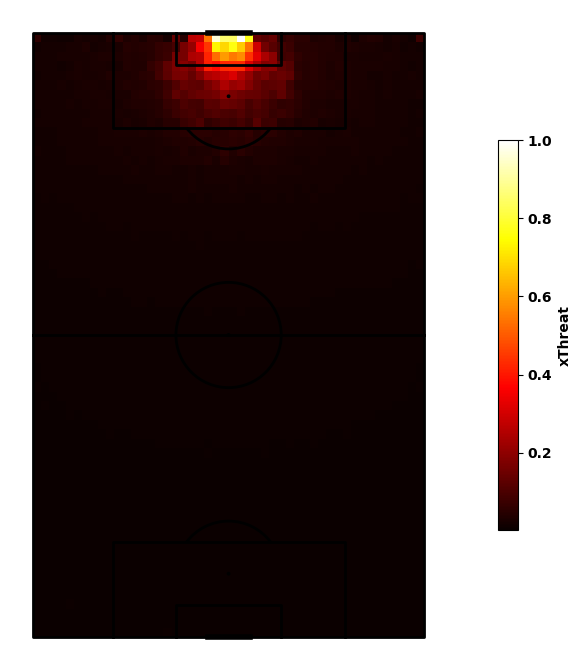

In [517]:
xT_true_16x12.plot_xThreat()
xT_true_32x24.plot_xThreat()
xT_true_64x48.plot_xThreat()

# Resampled models

In [518]:
df_errors = pd.read_csv('../2-calculate-values/bootstrap_errors_normal_xthreat.csv').rename(columns={'sample_size': 'N'})
df_errors['M'] = df_errors['n_x'] * df_errors['n_y']
df_errors['1/sqrt(N)'] = 1/np.sqrt(df_errors['N'])
df_errors['Mlog(M)/sqrt(N)'] = df_errors['M']*np.log(df_errors['M'])*df_errors['1/sqrt(N)']

# Make the norm a dimension independent norm
for col in df_errors.columns.tolist():
    if '1_norm' in col:
        df_errors[col] = df_errors[col]/df_errors['M']
    if ' 2_norm' in col:
        df_errors[col] = df_errors[col]/np.sqrt(df_errors['M'])

In [519]:
df_errors

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,xT_error_inf_norm,g_error_inf_norm,xG_error_inf_norm,prob_shot_error_inf_norm,transition_matrix_error_inf_norm,transition_matrix_true_inf_norm,transition_matrix_resampled_inf_norm,M,1/sqrt(N),Mlog(M)/sqrt(N)
0,16,12,4000000,0,5176042,0.000561,0.000314,0.007967,0.000580,0.000403,...,0.012561,0.010799,0.500000,0.022223,0.131414,1.0,1.0,192,0.000500,0.504720
1,16,12,4000000,1,5176043,0.000338,0.000166,0.006788,0.000344,0.000401,...,0.012944,0.010130,0.500000,0.008385,0.117864,1.0,1.0,192,0.000500,0.504720
2,16,12,4000000,2,5176044,0.000370,0.000248,0.009014,0.000351,0.000414,...,0.010126,0.011958,0.500000,0.006650,0.132075,1.0,1.0,192,0.000500,0.504720
3,16,12,4000000,3,5176045,0.000605,0.000350,0.005589,0.000430,0.000438,...,0.017236,0.015174,0.157143,0.011811,0.133729,1.0,1.0,192,0.000500,0.504720
4,16,12,4000000,4,5176046,0.000337,0.000259,0.008731,0.000483,0.000433,...,0.015648,0.017580,0.500000,0.012102,0.139206,1.0,1.0,192,0.000500,0.504720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,64,48,100000,995,4805037,0.010060,0.007286,0.024008,0.013091,0.001156,...,1.000000,1.000000,1.000000,1.000000,1.928571,1.0,1.0,3072,0.003162,78.008388
47996,64,48,100000,996,4805038,0.008690,0.006119,0.023058,0.011962,0.001202,...,1.000000,1.000000,1.000000,1.000000,1.884615,1.0,1.0,3072,0.003162,78.008388
47997,64,48,100000,997,4805039,0.009090,0.006422,0.022428,0.012409,0.001110,...,0.958333,0.920000,1.000000,1.000000,1.865385,1.0,1.0,3072,0.003162,78.008388
47998,64,48,100000,998,4805040,0.010046,0.006882,0.023307,0.012695,0.001056,...,1.000000,1.000000,1.000000,1.000000,1.879518,1.0,1.0,3072,0.003162,78.008388


In [520]:
df_errors[(df_errors['n_x'] == 16) & (df_errors['N'] == 630_000) & (df_errors['i_bootstrap'] == 900)][['xT_error_1_norm', 'xT_error_inf_norm', 'Mlog(M)/sqrt(N)']]

,xT_error_1_norm,xT_error_inf_norm,Mlog(M)/sqrt(N)
2900,0.001121,0.022994,1.271774


In [521]:
df_errors[(df_errors['n_x'] == 64) & (df_errors['N'] == 630_000) & (df_errors['i_bootstrap'] == 906)][['xT_error_1_norm', 'xT_error_inf_norm', 'Mlog(M)/sqrt(N)']]

,xT_error_1_norm,xT_error_inf_norm,Mlog(M)/sqrt(N)
42906,0.003632,0.538462,31.079286


In [522]:
df_errors[(df_errors['n_x'] == 32) & (df_errors['N'] == 4_000_000) & (df_errors['i_bootstrap'] == 900)][['xT_error_1_norm', 'xT_error_inf_norm', 'Mlog(M)/sqrt(N)']]

,xT_error_1_norm,xT_error_inf_norm,Mlog(M)/sqrt(N)
8900,0.000618,0.026991,2.551215


## Resampled 16x12 (630 000 events)

In [523]:
xT_resampled_16x12 = xThreat.load_from_pickle('../0-model-storage/xt-N630000-n_x16-n_y12-i_bootstrap900-random_state1806942.pickle')

(<Figure size 1050x680 with 2 Axes>,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x203319ace90>)

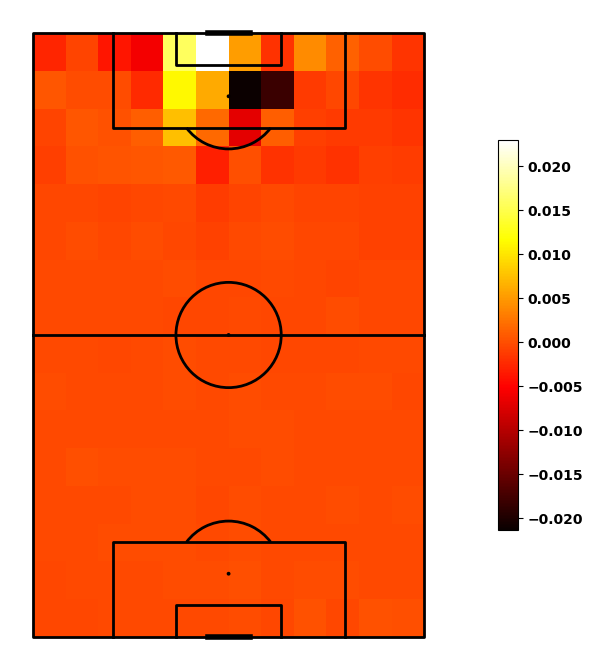

In [524]:
xT_resampled_16x12.plot_pitch_heatmap(xT_resampled_16x12.xT - xT_true_16x12.xT)

## Resampled 64x48 (630 000 events)

In [525]:
xT_resampled_64x48 = xThreat.load_from_pickle('../0-model-storage/xt-N630000-n_x64-n_y48-i_bootstrap906-random_state5334948.pickle')

(<Figure size 1050x680 with 2 Axes>,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x20345231ca0>)

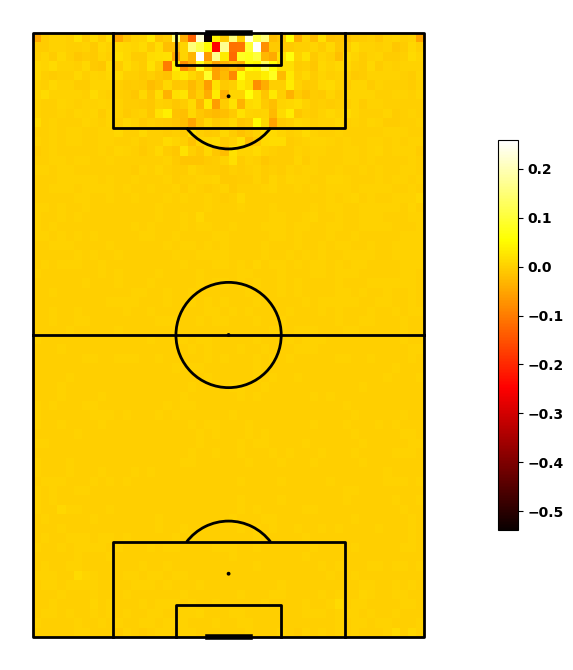

In [526]:
xT_resampled_64x48.plot_pitch_heatmap(xT_resampled_64x48.xT - xT_true_64x48.xT)

## Resampled 64x48 (630 000 events)

In [527]:
xT_resampled_32x24 = xThreat.load_from_pickle('../0-model-storage/xt-N4000000-n_x32-n_y24-i_bootstrap900-random_state6352942.pickle')

(<Figure size 1050x680 with 2 Axes>,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x2034a29eae0>)

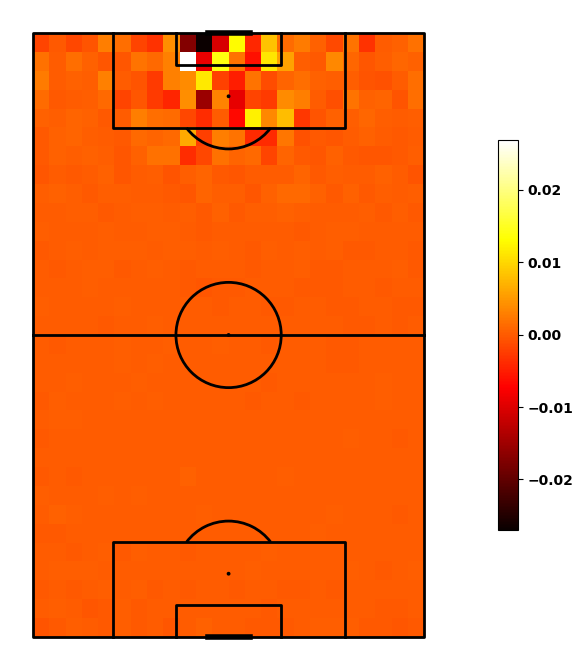

In [528]:
xT_resampled_32x24.plot_pitch_heatmap(xT_resampled_32x24.xT - xT_true_32x24.xT)

## Calculate resampled xT values

In [529]:
df_euros_filtered_resampled_16x12 = xT_resampled_16x12.quantify_action_quality(df_euros_filtered)
df_positive_resampled_16x12 = df_euros_filtered_resampled_16x12[df_euros_filtered_resampled_16x12['action_xT'] > 0]
df_positive_resampled_16x12 = df_positive_resampled_16x12.merge(filtered_players[['player_id', 'Minutes', 'main_position']], on='player_id', how='left')
df_positive_resampled_16x12['action_xT_sum'] = df_positive_resampled_16x12['action_xT']
df_positive_resampled_16x12['action_xT'] = df_positive_resampled_16x12['action_xT'] / df_positive_resampled_16x12['Minutes'] * 90

player_xT_df_resampled_16x12 = pd.DataFrame(df_positive_resampled_16x12.groupby('player_id')['action_xT'].sum()).rename(columns={'action_xT': 'action_xT_resampled_16x12'})
player_xT_df_resampled_16x12

,action_xT_resampled_16x12
player_id,
2954.0,0.183975
2988.0,0.363154
2999.0,0.111404
3009.0,0.156289
3026.0,0.125993
...,...
30328.0,0.082529
30486.0,0.241959
31900.0,0.260357


In [531]:
df_euros_filtered_resampled_64x48 = xT_resampled_64x48.quantify_action_quality(df_euros_filtered)
df_positive_resampled_64x48 = df_euros_filtered_resampled_64x48[df_euros_filtered_resampled_64x48['action_xT'] > 0]
df_positive_resampled_64x48 = df_positive_resampled_64x48.merge(filtered_players[['player_id', 'Minutes', 'main_position']], on='player_id', how='left')
df_positive_resampled_64x48['action_xT_sum'] = df_positive_resampled_64x48['action_xT']
df_positive_resampled_64x48['action_xT'] = df_positive_resampled_64x48['action_xT'] / df_positive_resampled_64x48['Minutes'] * 90
player_xT_df_resampled_64x48 = pd.DataFrame(df_positive_resampled_64x48.groupby('player_id')['action_xT'].sum()).rename(columns={'action_xT': 'action_xT_resampled_64x48'})
player_xT_df_resampled_64x48

,action_xT_resampled_64x48
player_id,
2954.0,0.156986
2988.0,0.377739
2999.0,0.136456
3009.0,0.153320
3026.0,0.132862
...,...
30328.0,0.095613
30486.0,0.263609
31900.0,0.225403


In [532]:
df_euros_filtered_resampled_32x24 = xT_resampled_32x24.quantify_action_quality(df_euros_filtered)
df_positive_resampled_32x24 = df_euros_filtered_resampled_32x24[df_euros_filtered_resampled_32x24['action_xT'] > 0]
df_positive_resampled_32x24 = df_positive_resampled_32x24.merge(filtered_players[['player_id', 'Minutes', 'main_position']], on='player_id', how='left')
df_positive_resampled_32x24['action_xT_sum'] = df_positive_resampled_32x24['action_xT']
df_positive_resampled_32x24['action_xT'] = df_positive_resampled_32x24['action_xT'] / df_positive_resampled_32x24['Minutes'] * 90
player_xT_df_resampled_32x24 = pd.DataFrame(df_positive_resampled_32x24.groupby('player_id')['action_xT'].sum()).rename(columns={'action_xT': 'action_xT_resampled_32x24'})
player_xT_df_resampled_32x24

,action_xT_resampled_32x24
player_id,
2954.0,0.163544
2988.0,0.397179
2999.0,0.130969
3009.0,0.161359
3026.0,0.123580
...,...
30328.0,0.093832
30486.0,0.258754
31900.0,0.219881


In [533]:
combined_player_xT_df

,player_id,action_xT_16x12,Player,action_xT_64x48,action_xT_32x24,diff_xT
103,7044.0,0.181979,Patrik Schick,0.118023,0.152334,-0.063956
120,31900.0,0.242756,Oleksandr Karavaev,0.188396,0.229077,-0.054359
123,16532.0,0.259927,Daniel Olmo Carvajal,0.208644,0.215694,-0.051283
132,8286.0,0.306989,Leonardo Spinazzola,0.259186,0.283593,-0.047804
108,2954.0,0.186994,Youri Tielemans,0.145590,0.165869,-0.041404
...,...,...,...,...,...,...
136,8966.0,0.336375,Kai Havertz,0.387633,0.392047,0.051257
131,24443.0,0.298068,Mikkel Damsgaard,0.352608,0.291989,0.054540
87,9929.0,0.145205,Diogo José Teixeira da Silva,0.204691,0.162757,0.059486
138,5207.0,0.343320,Cristiano Ronaldo dos Santos Aveiro,0.451639,0.383099,0.108320


In [534]:
combined_player_xT_df = combined_player_xT_df.merge(player_xT_df_resampled_16x12, on='player_id', how='left')
combined_player_xT_df = combined_player_xT_df.merge(player_xT_df_resampled_64x48, on='player_id', how='left')
combined_player_xT_df = combined_player_xT_df.merge(player_xT_df_resampled_32x24, on='player_id', how='left')

In [535]:
combined_player_xT_df

,player_id,action_xT_16x12,Player,action_xT_64x48,action_xT_32x24,diff_xT,action_xT_resampled_16x12,action_xT_resampled_64x48,action_xT_resampled_32x24
0,7044.0,0.181979,Patrik Schick,0.118023,0.152334,-0.063956,0.193690,0.131506,0.153000
1,31900.0,0.242756,Oleksandr Karavaev,0.188396,0.229077,-0.054359,0.260357,0.225403,0.219881
2,16532.0,0.259927,Daniel Olmo Carvajal,0.208644,0.215694,-0.051283,0.248619,0.226849,0.208803
3,8286.0,0.306989,Leonardo Spinazzola,0.259186,0.283593,-0.047804,0.297178,0.317463,0.283047
4,2954.0,0.186994,Youri Tielemans,0.145590,0.165869,-0.041404,0.183975,0.156986,0.163544
...,...,...,...,...,...,...,...,...,...
141,8966.0,0.336375,Kai Havertz,0.387633,0.392047,0.051257,0.339003,0.368477,0.400956
142,24443.0,0.298068,Mikkel Damsgaard,0.352608,0.291989,0.054540,0.297101,0.399537,0.291262
143,9929.0,0.145205,Diogo José Teixeira da Silva,0.204691,0.162757,0.059486,0.155087,0.268564,0.169014
144,5207.0,0.343320,Cristiano Ronaldo dos Santos Aveiro,0.451639,0.383099,0.108320,0.350996,0.483644,0.388044


In [536]:
combined_player_xT_df['diff_xT_16x12'] = combined_player_xT_df['action_xT_16x12'] - combined_player_xT_df['action_xT_resampled_16x12']
combined_player_xT_df['diff_xT_32x24'] = combined_player_xT_df['action_xT_32x24'] - combined_player_xT_df['action_xT_resampled_32x24']
combined_player_xT_df['diff_xT_64x48'] = combined_player_xT_df['action_xT_64x48'] - combined_player_xT_df['action_xT_resampled_64x48']
combined_player_xT_df

,player_id,action_xT_16x12,Player,action_xT_64x48,action_xT_32x24,diff_xT,action_xT_resampled_16x12,action_xT_resampled_64x48,action_xT_resampled_32x24,diff_xT_16x12,diff_xT_32x24,diff_xT_64x48
0,7044.0,0.181979,Patrik Schick,0.118023,0.152334,-0.063956,0.193690,0.131506,0.153000,-0.011711,-0.000666,-0.013484
1,31900.0,0.242756,Oleksandr Karavaev,0.188396,0.229077,-0.054359,0.260357,0.225403,0.219881,-0.017601,0.009197,-0.037007
2,16532.0,0.259927,Daniel Olmo Carvajal,0.208644,0.215694,-0.051283,0.248619,0.226849,0.208803,0.011308,0.006891,-0.018204
3,8286.0,0.306989,Leonardo Spinazzola,0.259186,0.283593,-0.047804,0.297178,0.317463,0.283047,0.009812,0.000546,-0.058277
4,2954.0,0.186994,Youri Tielemans,0.145590,0.165869,-0.041404,0.183975,0.156986,0.163544,0.003019,0.002325,-0.011396
...,...,...,...,...,...,...,...,...,...,...,...,...
141,8966.0,0.336375,Kai Havertz,0.387633,0.392047,0.051257,0.339003,0.368477,0.400956,-0.002628,-0.008909,0.019155
142,24443.0,0.298068,Mikkel Damsgaard,0.352608,0.291989,0.054540,0.297101,0.399537,0.291262,0.000967,0.000726,-0.046929
143,9929.0,0.145205,Diogo José Teixeira da Silva,0.204691,0.162757,0.059486,0.155087,0.268564,0.169014,-0.009882,-0.006257,-0.063873
144,5207.0,0.343320,Cristiano Ronaldo dos Santos Aveiro,0.451639,0.383099,0.108320,0.350996,0.483644,0.388044,-0.007677,-0.004944,-0.032005


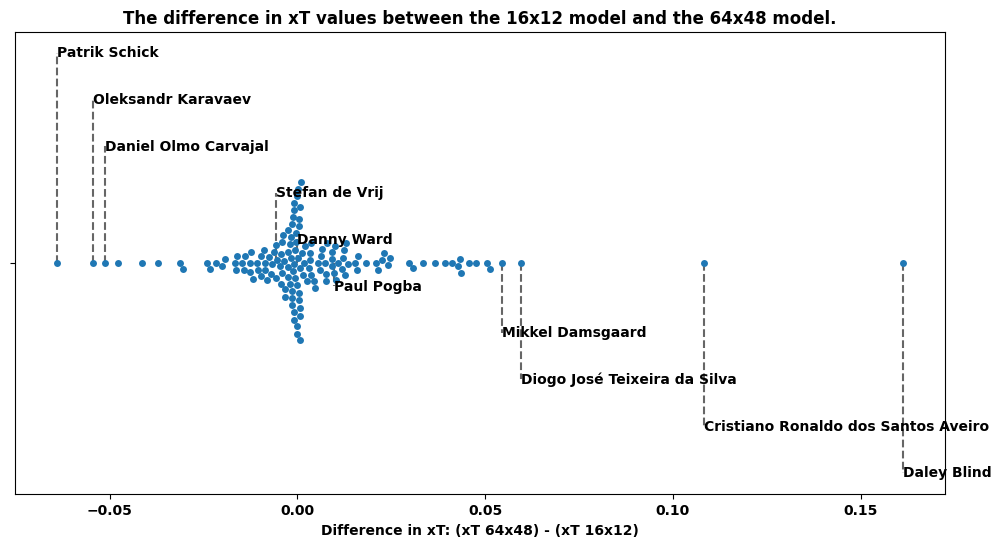

In [537]:
import numpy as np

# Sort values for annotation
combined_player_xT_df = combined_player_xT_df.sort_values('diff_xT')

# Select some key points for annotation: min, max, and quartiles
key_indices = [0, 1, 2, len(player_xT_df) // 4, len(combined_player_xT_df) // 2, 3 * len(combined_player_xT_df) // 4, len(combined_player_xT_df) - 4, len(combined_player_xT_df) - 3, len(combined_player_xT_df) - 2, len(combined_player_xT_df) - 1]
key_players = combined_player_xT_df.iloc[key_indices]

# Create beeswarm plot
plt.figure(figsize=(12, 6))
ax = sns.swarmplot(x=combined_player_xT_df['diff_xT'], orient='h', size=5)

# Annotate selected points with lines and staggered text positions
y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
for i, (_, row) in enumerate(key_players.iterrows()):
    plt.plot([row['diff_xT'], row['diff_xT']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
    plt.text(row['diff_xT'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

plt.xlabel('Difference in xT: (xT 64x48) - (xT 16x12)')
plt.title('The difference in xT values between the 16x12 model and the 64x48 model.')
plt.show()


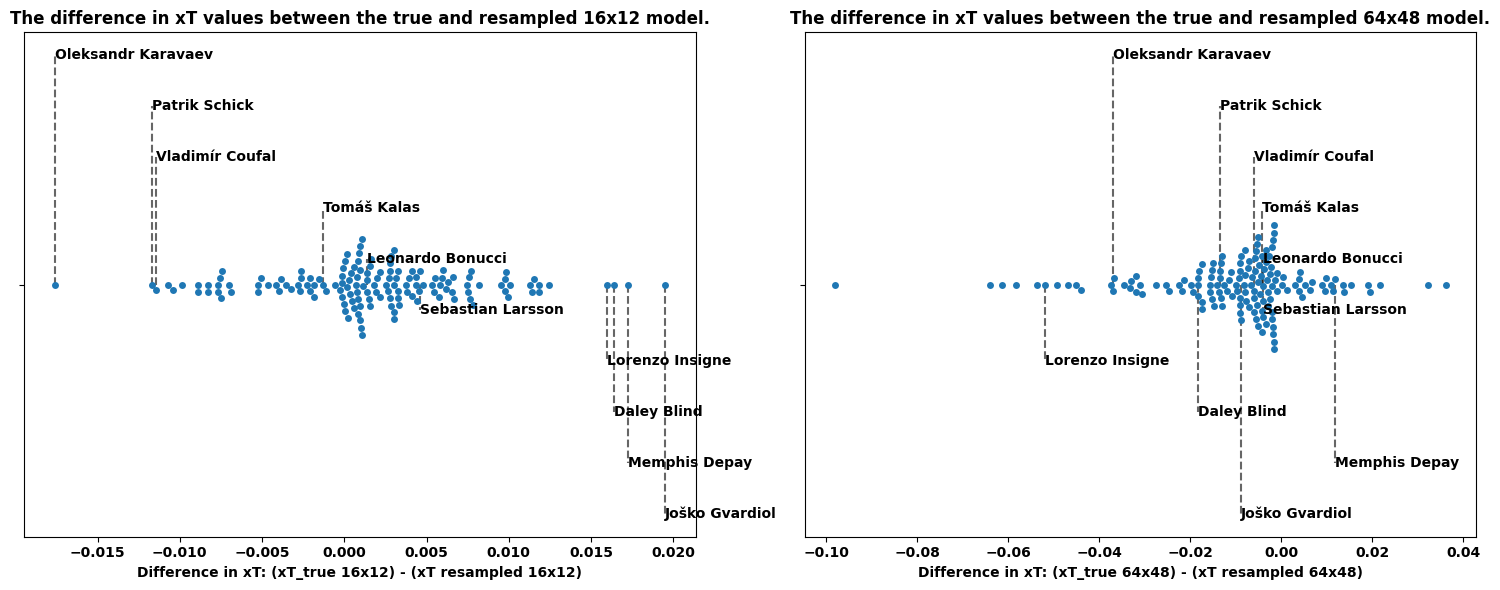

In [538]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sort values for annotation
combined_player_xT_df = combined_player_xT_df.sort_values('diff_xT_16x12')

# Select some key points for annotation: min, max, and quartiles
key_indices = [0, 1, 2, len(combined_player_xT_df) // 4, len(combined_player_xT_df) // 2, 3 * len(combined_player_xT_df) // 4, len(combined_player_xT_df) - 4, len(combined_player_xT_df) - 3, len(combined_player_xT_df) - 2, len(combined_player_xT_df) - 1]
key_players = combined_player_xT_df.iloc[key_indices]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))  # 1 row, 2 columns


# Create beeswarm plot
sns.swarmplot(x=combined_player_xT_df['diff_xT_16x12'], orient='h', size=5, ax=axes[0])

# Annotate selected points with lines and staggered text positions
y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
for i, (_, row) in enumerate(key_players.iterrows()):
    axes[0].plot([row['diff_xT_16x12'], row['diff_xT_16x12']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
    axes[0].text(row['diff_xT_16x12'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

axes[0].set_xlabel('Difference in xT: (xT_true 16x12) - (xT resampled 16x12)')
axes[0].set_title('The difference in xT values between the true and resampled 16x12 model.')


# Sort values for annotation
combined_player_xT_df = combined_player_xT_df.sort_values('diff_xT_64x48')
# Create beeswarm plot
sns.swarmplot(x=combined_player_xT_df['diff_xT_64x48'], orient='h', size=5, ax=axes[1])

# Annotate selected points with lines and staggered text positions
y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
for i, (_, row) in enumerate(key_players.iterrows()):
    axes[1].plot([row['diff_xT_64x48'], row['diff_xT_64x48']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
    axes[1].text(row['diff_xT_64x48'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

axes[1].set_xlabel('Difference in xT: (xT_true 64x48) - (xT resampled 64x48)')
axes[1].set_title('The difference in xT values between the true and resampled 64x48 model.')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


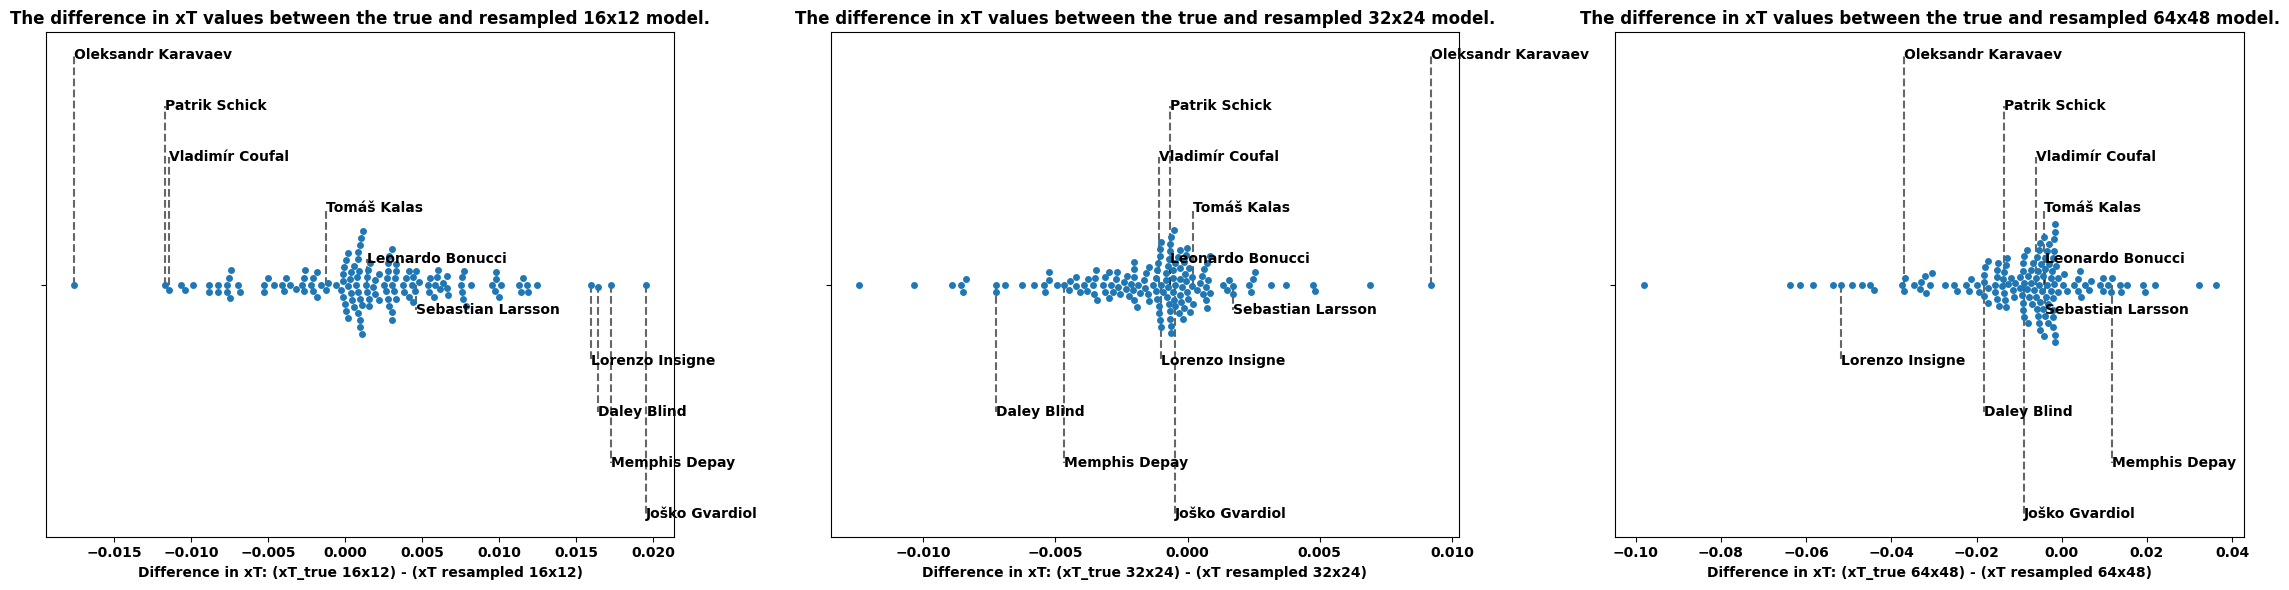

In [539]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sort values for annotation
combined_player_xT_df = combined_player_xT_df.sort_values('diff_xT_16x12')

# Select some key points for annotation: min, max, and quartiles
key_indices = [0, 1, 2, len(combined_player_xT_df) // 4, len(combined_player_xT_df) // 2, 3 * len(combined_player_xT_df) // 4, len(combined_player_xT_df) - 4, len(combined_player_xT_df) - 3, len(combined_player_xT_df) - 2, len(combined_player_xT_df) - 1]
key_players = combined_player_xT_df.iloc[key_indices]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(22.5, 6))  # 1 row, 2 columns

# Create beeswarm plot
sns.swarmplot(x=combined_player_xT_df['diff_xT_16x12'], orient='h', size=5, ax=axes[0])

# Annotate selected points with lines and staggered text positions
y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
for i, (_, row) in enumerate(key_players.iterrows()):
    axes[0].plot([row['diff_xT_16x12'], row['diff_xT_16x12']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
    axes[0].text(row['diff_xT_16x12'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

axes[0].set_xlabel('Difference in xT: (xT_true 16x12) - (xT resampled 16x12)')
axes[0].set_title('The difference in xT values between the true and resampled 16x12 model.')


# Sort values for annotation
combined_player_xT_df = combined_player_xT_df.sort_values('diff_xT_32x24')
# Create beeswarm plot
sns.swarmplot(x=combined_player_xT_df['diff_xT_32x24'], orient='h', size=5, ax=axes[1])

# Annotate selected points with lines and staggered text positions
y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
for i, (_, row) in enumerate(key_players.iterrows()):
    axes[1].plot([row['diff_xT_32x24'], row['diff_xT_32x24']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
    axes[1].text(row['diff_xT_32x24'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

axes[1].set_xlabel('Difference in xT: (xT_true 32x24) - (xT resampled 32x24)')
axes[1].set_title('The difference in xT values between the true and resampled 32x24 model.')


# Sort values for annotation
combined_player_xT_df = combined_player_xT_df.sort_values('diff_xT_64x48')
# Create beeswarm plot
sns.swarmplot(x=combined_player_xT_df['diff_xT_64x48'], orient='h', size=5, ax=axes[2])

# Annotate selected points with lines and staggered text positions
y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
for i, (_, row) in enumerate(key_players.iterrows()):
    axes[2].plot([row['diff_xT_64x48'], row['diff_xT_64x48']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
    axes[2].text(row['diff_xT_64x48'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

axes[2].set_xlabel('Difference in xT: (xT_true 64x48) - (xT resampled 64x48)')
axes[2].set_title('The difference in xT values between the true and resampled 64x48 model.')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()